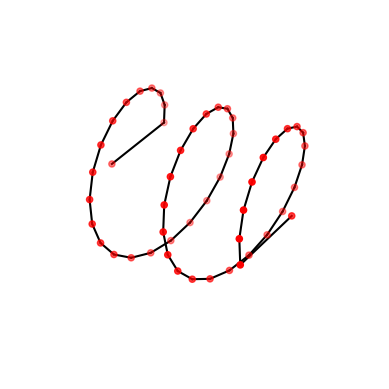

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=1e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=1)

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0, 1, robot.n_nodes-2, robot.n_nodes-1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)
robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

iter: 1, error: 0.211
iter: 2, error: 0.222
current_time:  0.01
iter: 1, error: 0.362
iter: 2, error: 0.677
current_time:  0.02
iter: 1, error: 0.498
iter: 2, error: 1.133
current_time:  0.03
iter: 1, error: 0.601
iter: 2, error: 1.453
current_time:  0.04
iter: 1, error: 0.667
iter: 2, error: 1.594
current_time:  0.05
iter: 1, error: 0.698
iter: 2, error: 1.591
current_time:  0.060000000000000005
iter: 1, error: 0.695
iter: 2, error: 1.513
current_time:  0.07
iter: 1, error: 0.662
iter: 2, error: 1.425
current_time:  0.08
iter: 1, error: 0.608
iter: 2, error: 1.363
current_time:  0.09
iter: 1, error: 0.538
iter: 2, error: 1.324
current_time:  0.09999999999999999
iter: 1, error: 0.463
iter: 2, error: 1.281
current_time:  0.10999999999999999
iter: 1, error: 0.392
iter: 2, error: 1.207
current_time:  0.11999999999999998
iter: 1, error: 0.337
iter: 2, error: 1.097
current_time:  0.12999999999999998
iter: 1, error: 0.310
iter: 2, error: 0.978
current_time:  0.13999999999999999
iter: 1, erro

In [3]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=4)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

26


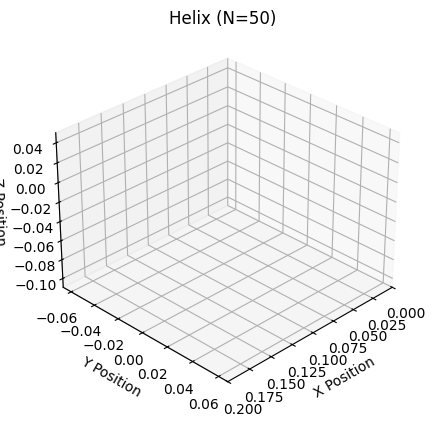

In [4]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky.gif')

In [5]:
# get centroid trajectory (correct)
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]                    # (T, 3*n)
nodes = qs_nodes.reshape(T, robot.n_nodes, 3)           # (T, n, 3)  where last dim is (x,y,z)
centroid_traj = nodes.mean(axis=1)                      # (T, 3)

vs_nodes = vs[:, :robot.n_nodes * 3]
nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)       # (T, n, 3)
centroid_vel = nodes_vel.mean(axis=1)                   # (T, 3)

# slinky length from last node x-coordinate (or use a known constant L if you have it)
slinky_len = nodes[-1, -1, 0]                           # x of last node at final time

start_block = np.tile([0.0, 0.0, 0.0], (T, 1))          # (T, 3)
end_block   = np.tile([slinky_len, 0.0, 0.0], (T, 1))   # (T, 3)

centerline_nodes_traj = np.hstack([start_block, centroid_traj, end_block])  # (T, 9)

centerline_edges_traj = np.zeros((T, 2))                # 3 nodes -> 2 edges

centerline_node_vel = np.hstack([
    np.zeros((T, 3)),
    centroid_vel,
    np.zeros((T, 3))
])                                                      # (T, 9)

centerline_angvel = np.zeros((T, 2))                    # 2 edges

xs_centerline = np.hstack([
    centerline_nodes_traj,
    centerline_edges_traj,
    centerline_node_vel,
    centerline_angvel
])                                                      # (T, 9+2+9+2) = (T, 22)

print("centerline state shape:", xs_centerline.shape)
print("centroid_traj[0], centroid_traj[-1]:", centroid_traj[0], centroid_traj[-1])

np.savez("slinky_centerline_3_nodes_truth.npz", xs_centerline=xs_centerline)

centerline state shape: (101, 22)
centroid_traj[0], centroid_traj[-1]: [ 1.00000000e-01 -4.00320802e-19  5.94746154e-03] [ 1.00000000e-01  4.91060184e-17 -2.63267981e-02]


In [6]:
x = qs_nodes[:, 0::3]
y = qs_nodes[:, 1::3]
z = qs_nodes[:, 2::3]
centroid_alt = np.stack([x.mean(axis=1), y.mean(axis=1), z.mean(axis=1)], axis=1)

print("max abs diff:", np.max(np.abs(centroid_traj - centroid_alt)))

max abs diff: 4.163336342344337e-17
